In [2]:
import numpy as np
import pandas as pd
import scipy.sparse.linalg as linalg
import scipy.linalg as slin
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import sys
sys.path.insert(0, '../data')
from load import load_stats, load_history

pd.options.mode.chained_assignment = None

In [3]:
players = load_stats()
history = load_history()

In [4]:
# # valid player defined as players who didn't gain more than 1500 points in their first tournament
# def valid_player(player):
#     r_hist = history[history['Database#'] == player['Database#']]
#     if len(r_hist) == 0:
#         return False

#     first_tournament = r_hist.iloc[-1]
#     if first_tournament['Final Rating'] - first_tournament['Initial Rating'] <= 1500:
#         return True
#     return False

# # filter out all invalid players
# players['Valid Player'] = players.apply(valid_player, axis=1)
# valid = players[['Database#', 'Valid Player']]
# history = history.merge(valid, how='inner', on='Database#')
# players = players[players['Valid Player'] == True]
# history = history[history['Valid Player'] == True]

In [5]:
# # valid tournament defined as any tournament with a change in rating less than 1500
# def valid_tournament(tournament):
#     if tournament['Final Rating'] - tournament['Initial Rating'] > 1500:
#         return False
#     return True

# history['valid tournament'] = history.apply(valid_tournament, axis=1)
# history = history[history['valid tournament'] == True]

In [6]:
transitions = history[['Initial Rating', 'Final Rating']]
probs = (transitions.value_counts() / transitions.value_counts().groupby(level=0).sum())

initial, final = zip(*probs.index)
ratings = np.sort(np.union1d(initial, final))
indices = np.arange(0, len(ratings))
rtoi = pd.Series(index=ratings, data=indices)
itor = pd.Series(index=indices, data=ratings)

p_size = ratings.size
p = np.zeros((p_size, p_size))

for i, f in probs.index:
    p[rtoi[i], rtoi[f]] = probs[i, f]

In [7]:
def plot_pi(pi):
    sns.scatterplot(x=ratings, y=pi, marker='.')
    plt.show()

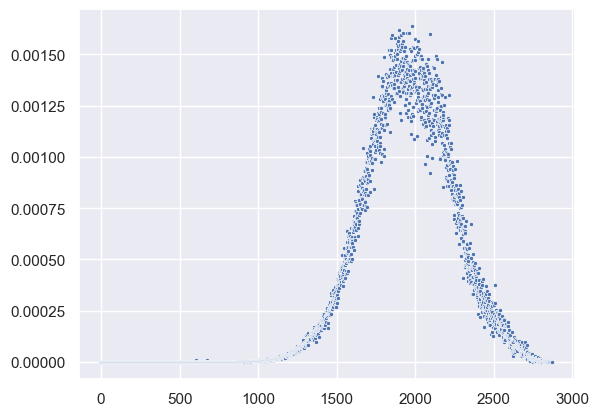

In [8]:
init_rating = 0
tournaments = 80

pi0 = np.zeros(p_size)
pi0[init_rating] = 1
pi = pi0 @ np.linalg.matrix_power(p, tournaments)
plot_pi(pi)

In [9]:
t = slin.eig(p, left=True, right=False)

In [10]:
reals = pd.Series(np.real(t[0]))
reals[reals > 0.95]

1    1.000000
2    0.992924
3    0.980104
4    0.967335
5    0.951282
dtype: float64

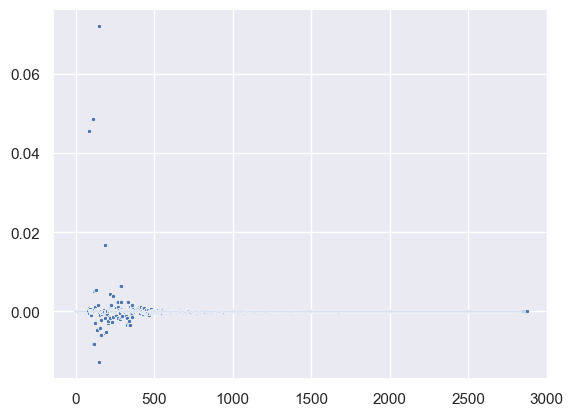

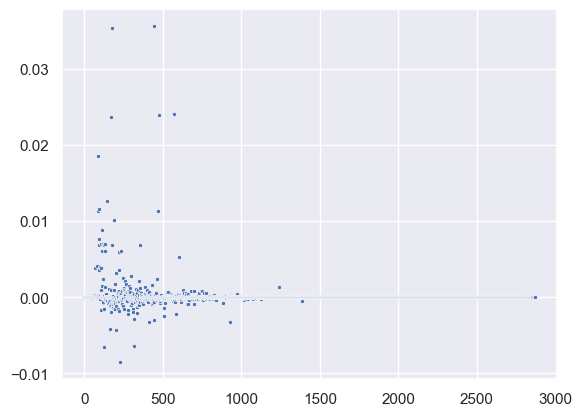

In [11]:
stationary = np.real(t[1][8])

pi = stationary @ np.linalg.matrix_power(p, 0)
plot_pi(pi)

pi = stationary @ np.linalg.matrix_power(p, 1)
plot_pi(pi)

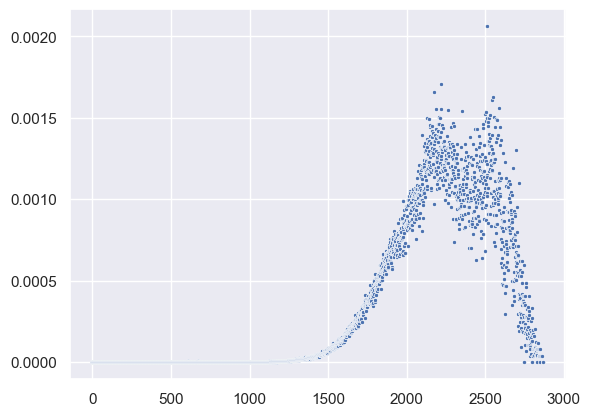

In [12]:
v = np.ones(p_size) / p_size  # Start with a uniform distribution
for _ in range(5000):
    v = v @ p
    v = v / np.sum(v)

plot_pi(v)

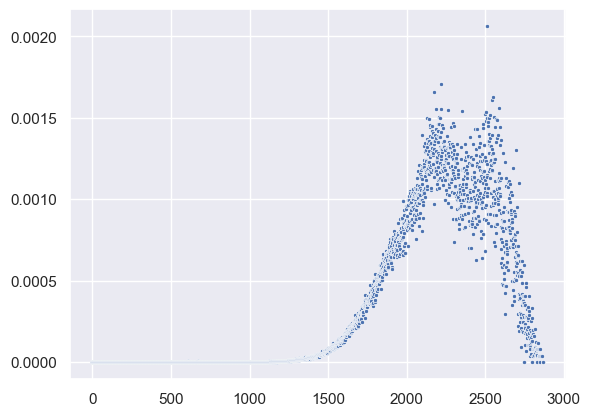

In [13]:
def stationary_distribution(P):
    n = P.shape[0]
    A = np.vstack([P.T - np.eye(n), np.ones(n)])
    b = np.append(np.zeros(n), 1)
    pi = np.linalg.lstsq(A, b, rcond=None)[0]
    return pi

plot_pi(stationary_distribution(p))